## 5.0 Data preparation identical to 1_data_preparation.ipynb

In [ ]:
# Install required packages
!pip install numpy pandas matplotlib scikit-learn xgboost lightgbm shap openpyxl scipy --quiet

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import shap
from collections import Counter
from matplotlib import pyplot as plt
from scipy.stats import rankdata

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score,
    balanced_accuracy_score, classification_report, confusion_matrix,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from utilz.Dataset import load_dataset
from utilz.constans import DISEASE, HEALTHY
from utilz.helpers import plot_roc_curve
from utilz.preprocessing_utilz import (
    ConstantExpressionReductor, AnovaReductor,
    MeanExpressionReductor, CovariatesBiasReductor,
)

meta_path = r"../data/samples_pancreatic.xlsx"
data_path = r"../data/counts_pancreatic.csv"
ds = load_dataset(data_path, meta_path, label_col="Group")

TEST_SIZE = 0.2
VALID_SIZE = 0.2
ANOVA_PERCENTILE = 60
MEAN_PERCENTILE = 20

ds.y = ds.y.replace({DISEASE: HEALTHY})

le = LabelEncoder()
y_encoded = pd.Series(le.fit_transform(ds.y), index=ds.y.index)
X_train, X_test, X_valid, y_train, y_test, y_valid = (
    ds.get_train_test_valid_split(ds.X, y_encoded, test_size=TEST_SIZE, valid_size=VALID_SIZE)
)
print("Class mapping:")
print(f"{le.classes_[0]} -> {le.transform(le.classes_)[0]}")
print(f"{le.classes_[1]} -> {le.transform(le.classes_)[1]}")

print("Encoded label distribution:")
print(y_encoded.value_counts().sort_index())
sex_numeric = ds.sex.map({"F": 0, "M": 1})

pipeline = Pipeline([
    ('ConstantExpressionReductor', ConstantExpressionReductor()),
    ('AnovaReductor', AnovaReductor(percentile=ANOVA_PERCENTILE)),
    ('MeanExpressionReductor', MeanExpressionReductor(percentile=MEAN_PERCENTILE)),
    ('AgeBiasReductor', CovariatesBiasReductor(covariate=ds.age)),
    ('SexBiasReductor', CovariatesBiasReductor(covariate=sex_numeric)),
    ('scaler', StandardScaler()),
])

X_train = pipeline.fit_transform(X_train, y_train)
X_valid = pipeline.transform(X_valid)
X_test = pipeline.transform(X_test)

---

## 5. Ensemble model

We combine three classifiers - Logistic Regression, LightGBM, and XGBoost - using a StackingClassifier.

All base models use hyperparameters from grid search. Decision threshold is tuned on the validation set (Youden's J statistic).


In [ ]:
class_counts = Counter(y_train)
scale_pos_weight = class_counts[0] / class_counts[1]

logreg = LogisticRegression(
    solver='saga', max_iter=15000, class_weight='balanced', fit_intercept=True, l1_ratio=0.2
)


xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight, n_estimators=500, random_state=2137
)
lgbm = LGBMClassifier(n_estimators=200, learning_rate=0.05, random_state=42, verbose=-1)

In [ ]:
for name, model in [("LogReg", logreg), ("LGBM", lgbm), ("XGB", xgb)]:
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Threshold tuning on validation set (Youden's J)
    y_valid_prob = model.predict_proba(X_valid)[:, 1]
    fpr_v, tpr_v, thr_v = roc_curve(y_valid, y_valid_prob)
    best_thr = thr_v[np.argmax(tpr_v - fpr_v)]
    y_pred = (y_prob >= best_thr).astype(int)

    print(f"{name:6s} | AUC: {roc_auc_score(y_test, y_prob):.4f} "
          f"| F1(w): {f1_score(y_test, y_pred, average='weighted'):.4f} "
          f"| BalAcc: {balanced_accuracy_score(y_test, y_pred):.4f} "
          f"| Threshold: {best_thr:.4f}")



### 5.2. StackingClassifier
Stacking with a LogisticRegression meta-learner trained on base model predictions (predict_proba).

In [ ]:
stacking = StackingClassifier(
    estimators=[('logreg', logreg), ('xgb', xgb), ('lgbm', lgbm)],
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=100),
    cv=StratifiedKFold(n_splits=2, shuffle=True, random_state=42),
    stack_method='predict_proba',
    passthrough=False
)

stacking.fit(X_train, y_train)
scores_valid_raw = stacking.predict_proba(X_valid)[:, 1]
scores_test_raw = stacking.predict_proba(X_test)[:, 1]

# Threshold tuning on validation set (Youden's J)
fpr_v, tpr_v, thresholds_v = roc_curve(y_valid, scores_valid_raw)
raw_threshold = thresholds_v[np.argmax(tpr_v - fpr_v)]

y_pred_raw = (scores_test_raw >= raw_threshold).astype(int)

print(f"Optimal threshold: {raw_threshold:.4f}")
print(f"AUC:               {roc_auc_score(y_test, scores_test_raw):.4f}")
print(f"F1 (weighted):     {f1_score(y_test, y_pred_raw, average='weighted'):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred_raw):.4f}")
print(f"\n{classification_report(y_test, y_pred_raw, target_names=le.classes_)}")
print(f"Confusion matrix:\n{confusion_matrix(y_test, y_pred_raw)}")
plot_roc_curve(scores_test_raw, y_test, "logistic regression")

---

## 6. SHAP - Feature importance analysis

SHAP (SHapley Additive exPlanations) values quantify each feature's contribution to individual predictions. We compute SHAP values for each base model (Logistic Regression, LightGBM, XGBoost) to identify the most important genes driving the cancer vs. control classification.

### 6.1. SHAP for Logistic Regression

For linear models, SHAP values can be computed efficiently using the `LinearExplainer`. The coefficients directly map to feature contributions.

In [ ]:
feature_names = list(pipeline.named_steps['SexBiasReductor'].selected_genes_)
explainer_lr = shap.LinearExplainer(logreg, X_train)
shap_values_lr = explainer_lr.shap_values(X_test)
shap.summary_plot(shap_values_lr, X_test, feature_names=feature_names, max_display=10, show=True)

### 6.2. SHAP for LightGBM

LightGBM is a gradient boosting framework that natively supports `TreeExplainer`, allowing efficient and exact computation of SHAP values using the tree structure.

In [ ]:
explainer_lgbm = shap.TreeExplainer(lgbm)
shap_values_lgbm = explainer_lgbm.shap_values(X_test)
if isinstance(shap_values_lgbm, list):
    shap_values_lgbm_c1 = shap_values_lgbm[1]
else:
    shap_values_lgbm_c1 = shap_values_lgbm
print(f"SHAP values shape (LGBM): {shap_values_lgbm_c1.shape}")
shap.summary_plot(shap_values_lgbm_c1, X_test, feature_names=feature_names, max_display=5, show=True)

### 6.3. SHAP for XGBoost

XGBoost natively supports `TreeExplainer`, which computes exact SHAP values efficiently using the tree structure.

In [ ]:
explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test)
shap.summary_plot(shap_values_xgb, X_test, feature_names=feature_names, max_display=5, show=True)

### 6.4. Stacking-weighted SHAP gene ranking

Combined gene importance score: for each gene we multiply its mean |SHAP| by the weight that the stacking meta-learner assigns to that base model, then sum across all three models:

$$\text{score}(g) = \sum_{m \in \{\text{LR, LGBM, XGB}\}} \overline{|\text{SHAP}_m(g)|} \times w_m$$

where $w_m$ comes from the meta-learner's `coef_` (normalized to sum to 1). This directly reflects how much the final ensemble relies on each base model's predictions.

While the ensemble improved classification metrics over individual base models, the primary goal is to enhance the reliability of gene identification rather than maximize performance scores. The stacking-weighted SHAP ranking highlights genes that are consistently important across all models, with greater emphasis on those contributing most to the final ensemble decision.

In [ ]:
meta_coef = stacking.final_estimator_.coef_[0]
n_models = len(stacking.estimators_)
raw_weights = np.abs(meta_coef)

w = raw_weights / raw_weights.sum()
model_names = [name for name, _ in stacking.estimators]

print("Meta-learner weights (normalized):")
for name, wi, ri in zip(model_names, w, raw_weights):
    print(f"  {name:6s}:  w = {wi:.4f}  (raw |coef| = {ri:.4f})")

mean_abs_lr = np.abs(shap_values_lr).mean(axis=0)
mean_abs_lgbm = np.abs(shap_values_lgbm_c1).mean(axis=0)
mean_abs_xgb = np.abs(shap_values_xgb).mean(axis=0)

def minmax_norm(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-10)

shap_map = {
    'logreg': minmax_norm(mean_abs_lr),
    'lgbm':   minmax_norm(mean_abs_lgbm),
    'xgb':    minmax_norm(mean_abs_xgb),
}

weighted_score = np.zeros_like(list(shap_map.values())[0])
for i in range(len(stacking.estimators)):
    name, _ = stacking.estimators[i]
    wi = w[i]
    weighted_score += shap_map[name] * wi

ranking_df = pd.DataFrame({
    'gene': feature_names,
    'SHAP_LR': mean_abs_lr,
    'SHAP_LGBM': mean_abs_lgbm,
    'SHAP_XGB': mean_abs_xgb,
    'stacking_weighted_score': weighted_score,
}).sort_values('stacking_weighted_score', ascending=False).reset_index(drop=True)

ranking_df.index += 1
ranking_df.index.name = 'rank'

print("Top 20 genes by stacking-weighted SHAP score:")
ranking_df.head(20)

In [ ]:
top20 = ranking_df.head(20).copy()

fig, ax = plt.subplots(figsize=(10, 7))
genes = top20['gene'].values
y_pos = np.arange(len(genes))

w_dict = {name: wi for (name, _), wi in zip(stacking.estimators, w)}
bar_lr = top20['SHAP_LR'].values * w_dict['logreg']
bar_lgbm = top20['SHAP_LGBM'].values * w_dict['lgbm']
bar_xgb = top20['SHAP_XGB'].values * w_dict['xgb']

ax.barh(y_pos, bar_lr, label=f'LogReg (w={w_dict["logreg"]:.3f})', color='#6366f1')
ax.barh(y_pos, bar_lgbm, left=bar_lr, label=f'LGBM (w={w_dict["lgbm"]:.3f})', color='#f59e0b')
ax.barh(y_pos, bar_xgb, left=bar_lr + bar_lgbm, label=f'XGB (w={w_dict["xgb"]:.3f})', color='#10b981')

ax.set_yticks(y_pos)
ax.set_yticklabels(genes, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Stacking-weighted mean |SHAP|')
ax.set_title('Top 20 genes by stacking-weighted SHAP importance')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

Logistic Regression on Top 20 genes
Optimal threshold: 0.5444
AUC:               0.7686
F1 (weighted):     0.7730
Balanced accuracy: 0.7192

                       precision    recall  f1-score   support

Asymptomatic controls       0.91      0.77      0.84        92
    Pancreatic cancer       0.40      0.67      0.50        21

             accuracy                           0.75       113
            macro avg       0.66      0.72      0.67       113
         weighted avg       0.82      0.75      0.77       113

Confusion matrix:
[[71 21]
 [ 7 14]]
ROC AUC = 0.769


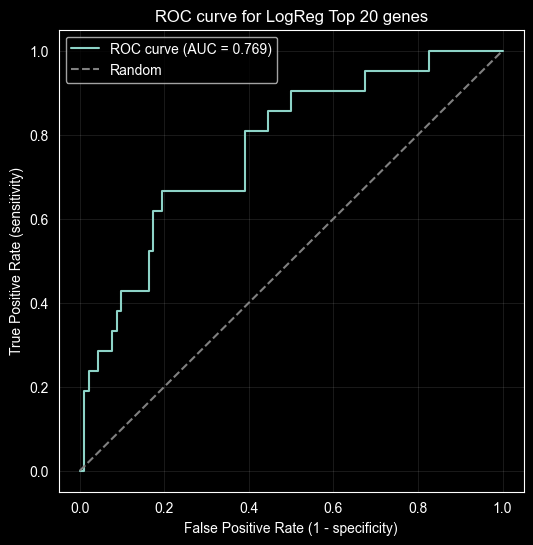

In [77]:
top_genes = ranking_df.head(20)['gene'].tolist()

X_train_top = pd.DataFrame(X_train, columns=feature_names)[top_genes]
X_valid_top = pd.DataFrame(X_valid, columns=feature_names)[top_genes]
X_test_top  = pd.DataFrame(X_test,  columns=feature_names)[top_genes]

logreg = LogisticRegression(
    solver='saga', max_iter=15000, class_weight='balanced', fit_intercept=True
)
logreg.fit(X_train_top, y_train)

y_valid_prob = logreg.predict_proba(X_valid_top)[:, 1]
fpr_v, tpr_v, thr_v = roc_curve(y_valid, y_valid_prob)
best_thr = thr_v[np.argmax(tpr_v - fpr_v)]

y_test_prob = logreg.predict_proba(X_test_top)[:, 1]
y_pred      = (y_test_prob >= best_thr).astype(int)

auc = roc_auc_score(y_test, y_test_prob)
f1  = f1_score(y_test, y_pred, average='weighted')
ba  = balanced_accuracy_score(y_test, y_pred)

print(f"Logistic Regression on Top 20 genes")
print(f"{'='*50}")
print(f"Optimal threshold: {best_thr:.4f}")
print(f"AUC:               {auc:.4f}")
print(f"F1 (weighted):     {f1:.4f}")
print(f"Balanced accuracy: {ba:.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=le.classes_)}")
print(f"Confusion matrix:\n{confusion_matrix(y_test, y_pred)}")

plot_roc_curve(y_test_prob, y_test, "LogReg Top 20 genes")